In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cho_factor, cho_solve
from statistics import NormalDist
from sklearn.model_selection import train_test_split
import pandas as pd

# Baseline Models #

For these models, assume that $$S_{t,c}=S_{t-1,c}+\epsilon_{t,c},$$ $$Y_{t,c}=S_{t,c}+\eta_{t,c},$$ where $S_{t,c}$ is latent and $Y_{t,c}$ is observed, $\eta_{t,c}\stackrel{\text{i.i.d.}}{\sim}\mathcal{N}(0,\tau^2)$, and $\epsilon_{t,c}$ is a mean-zero GP with $\text{AR}(1)$ structure in $t$, with marginal variance $\sigma^2$ and correlation $\rho$, independently over $c$. Assume furthermore that $$S_{0,c}=0.$$ These models eliminate the $\mu_{t,c}$ from our previous models, thus removing the information from the spatial and socioeconomic covariates we had before.

The following code takes in a $k\times n$ matrix $X$, where each row of $X$ is assumed to be an independent observed trajectory, and uses EM with a Kalman filter to approximately maximize the marginal likelihood with respect to $\rho,\sigma^2,\tau^2$.

In [2]:
def ar1_covariance(sigma2, rho, n):
    """
    Stationary AR(1) covariance matrix for U_1, ..., U_n.

    Var(U_t) = sigma2
    Corr(U_t, U_s) = rho^{|t-s|}
    """
    idx = np.arange(n)
    return sigma2 * rho ** np.abs(idx[:, None] - idx[None, :])


def cumulative_sum_matrix(n):
    """
    Matrix L such that Z = L U, where Z_t = U_1 + ... + U_t.
    """
    return np.tril(np.ones((n, n)))


def posterior_increments(X, rho, sigma2, tau2, jitter=1e-9):
    """
    Compute posterior distribution of U_1, ..., U_n given X_1, ..., X_n
    for k iid trajectories.

    Model:
        U ~ N(0, K_U)
        Z = L U
        X = Z + eta, eta ~ N(0, tau2 I)
    """
    X = np.asarray(X, dtype=float)

    if X.ndim == 1:
        X = X[None, :]

    k, n = X.shape

    K_U = ar1_covariance(sigma2, rho, n)
    L = cumulative_sum_matrix(n)

    S = L @ K_U @ L.T + tau2 * np.eye(n)
    S = S + jitter * np.eye(n)

    c, low = cho_factor(S, lower=True, check_finite=False)

    KUt_LT = K_U @ L.T

    # alpha = S^{-1} X^T, solved for all trajectories at once.
    alpha = cho_solve((c, low), X.T, check_finite=False)

    # E[U | X]
    post_mean_U = (KUt_LT @ alpha).T

    # Cov(U | X)
    post_cov_U = K_U - KUt_LT @ cho_solve(
        (c, low), KUt_LT.T, check_finite=False
    )
    post_cov_U = 0.5 * (post_cov_U + post_cov_U.T)

    # Marginal log-likelihood.
    logdet = 2.0 * np.sum(np.log(np.diag(c)))
    quad = np.sum(X * alpha.T)

    loglik = -0.5 * (
        k * n * np.log(2.0 * np.pi)
        + k * logdet
        + quad
    )

    return post_mean_U, post_cov_U, loglik


def update_ar1_parameters_conditional(
    post_mean_U,
    post_cov_U,
    rho_bounds=(1e-6, 0.999),
    fixed_rho=None,
    var_floor=1e-10,
):
    """
    Conditional-likelihood M-step for AR(1) increments, conditioning on U_1.

    Uses transitions U_t | U_{t-1}, t = 2, ..., n.

    If fixed_rho is None:
        rho is updated by the conditional least-squares formula.

    If fixed_rho is supplied:
        rho is held fixed, and only sigma2 is updated.

    In either case, the innovation variance is estimated as

        q = average E[(U_t - rho U_{t-1})^2 | X],

    and then

        sigma2 = q / (1 - rho^2).
    """
    post_mean_U = np.asarray(post_mean_U, dtype=float)
    post_cov_U = np.asarray(post_cov_U, dtype=float)

    k, n = post_mean_U.shape

    if n < 2:
        raise ValueError("Need n >= 2 to update AR(1) parameters.")

    diag_cov = np.diag(post_cov_U)

    # Python indices:
    # previous = U_1, ..., U_{n-1}
    # current  = U_2, ..., U_n
    E_Uprev_sq_by_t = (
        k * diag_cov[:-1]
        + np.sum(post_mean_U[:, :-1] ** 2, axis=0)
    )

    E_Ucurr_sq_by_t = (
        k * diag_cov[1:]
        + np.sum(post_mean_U[:, 1:] ** 2, axis=0)
    )

    lag_cov = np.array([post_cov_U[t, t - 1] for t in range(1, n)])

    E_Ucurr_Uprev_by_t = (
        k * lag_cov
        + np.sum(post_mean_U[:, 1:] * post_mean_U[:, :-1], axis=0)
    )

    S00 = np.sum(E_Uprev_sq_by_t)
    S11 = np.sum(E_Ucurr_sq_by_t)
    S10 = np.sum(E_Ucurr_Uprev_by_t)

    if fixed_rho is None:
        if S00 <= var_floor:
            rho_new = rho_bounds[0]
        else:
            rho_new = S10 / S00

        rho_new = float(np.clip(rho_new, rho_bounds[0], rho_bounds[1]))
    else:
        rho_new = float(fixed_rho)
        if not (rho_bounds[0] <= rho_new <= rho_bounds[1]):
            raise ValueError(
                f"fixed_rho={fixed_rho} is outside rho_bounds={rho_bounds}."
            )

    sse = S11 - 2.0 * rho_new * S10 + rho_new**2 * S00

    q_new = sse / (k * (n - 1))
    q_new = max(float(q_new), var_floor)

    sigma2_new = q_new / max(1.0 - rho_new**2, var_floor)
    sigma2_new = max(float(sigma2_new), var_floor)

    return rho_new, sigma2_new, q_new


def update_observation_variance(X, post_mean_U, post_cov_U, var_floor=1e-10):
    """
    M-step update for tau2 under iid observation noise.

    Since X = L U + eta,

        tau2 = average E[||X - L U||^2 | X].
    """
    X = np.asarray(X, dtype=float)

    if X.ndim == 1:
        X = X[None, :]

    k, n = X.shape
    L = cumulative_sum_matrix(n)

    post_mean_Z = post_mean_U @ L.T

    post_cov_Z = L @ post_cov_U @ L.T
    post_cov_Z = 0.5 * (post_cov_Z + post_cov_Z.T)

    post_var_Z = np.diag(post_cov_Z)

    residual_mean_part = np.sum((X - post_mean_Z) ** 2)
    residual_variance_part = k * np.sum(post_var_Z)

    tau2_new = (residual_mean_part + residual_variance_part) / (k * n)
    tau2_new = max(float(tau2_new), var_floor)

    return tau2_new, post_mean_Z, post_cov_Z


def fit_em_multiple_trajectories(
    X,
    init=None,
    fixed_rho=None,
    fixed_tau2=None,
    max_iter=200,
    tol=1e-6,
    rho_bounds=(1e-6, 0.999),
    var_floor=1e-10,
    jitter=1e-9,
    verbose=True,
):
    """
    Fit the cumulative latent AR(1)-increment model by EM.

    Model:
        U_1, ..., U_n are stationary AR(1) increments with

            Var(U_t) = sigma2,
            Corr(U_t, U_s) = rho^{|t-s|}.

        Z_t = U_1 + ... + U_t.

        X_t = Z_t + eta_t,

        eta_t iid N(0, tau2).

    Rows of X are iid trajectories.

    The E-step uses fast batch Gaussian conditioning.

    The M-step uses the conditional AR(1) likelihood for U_2, ..., U_n
    given U_1.

    Parameters
    ----------
    X : ndarray, shape (k, n)
        Rows are iid observed trajectories.

    init : dict or None
        Optional initial values. Example:

            init = {"rho": 0.5, "sigma2": 2.0, "tau2": 20.0}

    fixed_rho : float or None
        If supplied, rho is held fixed at this value.

    fixed_tau2 : float or None
        If supplied, tau2 is held fixed at this value.

    rho_bounds : tuple
        Bounds for rho. By default, rho is constrained positive.

        To allow negative rho, use:

            rho_bounds=(-0.999, 0.999)
    """
    X = np.asarray(X, dtype=float)

    if X.ndim == 1:
        X = X[None, :]

    k, n = X.shape

    if n < 2:
        raise ValueError("Need trajectories of length at least 2.")

    if init is None:
        rho = 0.5
        sigma2 = 1.0
        tau2 = 1.0
    else:
        rho = float(init.get("rho", 0.5))
        sigma2 = float(init.get("sigma2", 1.0))
        tau2 = float(init.get("tau2", 1.0))

    if fixed_rho is not None:
        rho = float(fixed_rho)

    if fixed_tau2 is not None:
        tau2 = float(fixed_tau2)

    if not (rho_bounds[0] <= rho <= rho_bounds[1]):
        raise ValueError(f"Initial/fixed rho={rho} is outside rho_bounds={rho_bounds}.")

    rho = float(np.clip(rho, rho_bounds[0], rho_bounds[1]))
    sigma2 = max(float(sigma2), var_floor)
    tau2 = max(float(tau2), var_floor)

    loglik_trace = []
    param_trace = []

    post_mean_U = None
    post_cov_U = None
    post_mean_Z = None
    post_cov_Z = None

    for it in range(max_iter):
        old_params = np.array([rho, sigma2, tau2], dtype=float)

        # E-step
        post_mean_U, post_cov_U, loglik = posterior_increments(
            X,
            rho=rho,
            sigma2=sigma2,
            tau2=tau2,
            jitter=jitter,
        )

        # M-step for rho and sigma2.
        rho_new, sigma2_new, q_new = update_ar1_parameters_conditional(
            post_mean_U,
            post_cov_U,
            rho_bounds=rho_bounds,
            fixed_rho=fixed_rho,
            var_floor=var_floor,
        )

        # M-step for tau2, unless fixed.
        if fixed_tau2 is None:
            tau2_new, post_mean_Z, post_cov_Z = update_observation_variance(
                X,
                post_mean_U,
                post_cov_U,
                var_floor=var_floor,
            )
        else:
            tau2_new = float(fixed_tau2)

            # Still compute posterior Z summaries for output.
            L = cumulative_sum_matrix(n)
            post_mean_Z = post_mean_U @ L.T
            post_cov_Z = L @ post_cov_U @ L.T
            post_cov_Z = 0.5 * (post_cov_Z + post_cov_Z.T)

        rho, sigma2, tau2 = rho_new, sigma2_new, tau2_new

        new_params = np.array([rho, sigma2, tau2], dtype=float)

        rel_change = np.max(
            np.abs(new_params - old_params)
            / np.maximum(np.abs(old_params), var_floor)
        )

        loglik_trace.append(loglik)

        param_trace.append(
            {
                "iter": it,
                "rho": rho,
                "sigma2": sigma2,
                "tau2": tau2,
                "q": q_new,
                "loglik": loglik,
                "rel_change": rel_change,
                "fixed_rho": fixed_rho is not None,
                "fixed_tau2": fixed_tau2 is not None,
            }
        )

        if verbose:
            print(
                f"iter={it:03d} "
                f"loglik={loglik:.6f} "
                f"rho={rho:.6g} "
                f"sigma2={sigma2:.6g} "
                f"tau2={tau2:.6g} "
                f"q={q_new:.6g} "
                f"rel_change={rel_change:.3e}"
            )

        if rel_change < tol:
            break

    # Final E-step under fitted parameters.
    post_mean_U, post_cov_U, final_loglik = posterior_increments(
        X,
        rho=rho,
        sigma2=sigma2,
        tau2=tau2,
        jitter=jitter,
    )

    L = cumulative_sum_matrix(n)
    post_mean_Z = post_mean_U @ L.T
    post_cov_Z = L @ post_cov_U @ L.T
    post_cov_Z = 0.5 * (post_cov_Z + post_cov_Z.T)

    return {
        "rho": rho,
        "sigma2": sigma2,
        "tau2": tau2,
        "q": sigma2 * (1.0 - rho**2),
        "fixed_rho": fixed_rho is not None,
        "fixed_tau2": fixed_tau2 is not None,
        "loglik_trace": np.array(loglik_trace),
        "param_trace": param_trace,
        "final_loglik": final_loglik,
        "posterior_mean_U": post_mean_U,
        "posterior_cov_U": post_cov_U,
        "posterior_mean_Z": post_mean_Z,
        "posterior_cov_Z": post_cov_Z,
        "posterior_var_Z": np.diag(post_cov_Z),
    }

# Simulating Data from the Model #

The following code simulates a matrix $X\in\mathbb{R}^{k\times n}$ from the above model, for given $\rho,\sigma^2,\tau^2$.

In [3]:
def simulate_ar1_cumsum_observations(k, n, rho, sigma2, tau2, random_state=None):
    """
    Simulate k iid trajectories of length n from:

        U_1 ~ N(0, sigma2)
        U_t = rho U_{t-1} + eps_t,
        eps_t ~ N(0, sigma2 * (1 - rho^2))

        Z_t = U_1 + ... + U_t
        X_t = Z_t + eta_t,
        eta_t ~ N(0, tau2)

    Parameters
    ----------
    k : int
        Number of iid trajectories.
    n : int
        Length of each trajectory.
    rho : float
        AR(1) correlation parameter. Should satisfy |rho| < 1.
    sigma2 : float
        Marginal variance of U_t.
    tau2 : float
        Observation noise variance.
    random_state : int, np.random.Generator, or None
        Random seed or generator.

    Returns
    -------
    X : ndarray, shape (k, n)
        Observed trajectories.
    Z : ndarray, shape (k, n)
        Latent cumulative trajectories.
    U : ndarray, shape (k, n)
        Latent AR(1) increments.
    """
    if not (-1 < rho < 1):
        raise ValueError("rho must satisfy -1 < rho < 1.")
    if sigma2 < 0:
        raise ValueError("sigma2 must be nonnegative.")
    if tau2 < 0:
        raise ValueError("tau2 must be nonnegative.")
    if k <= 0 or n <= 0:
        raise ValueError("k and n must be positive integers.")

    if isinstance(random_state, np.random.Generator):
        rng = random_state
    else:
        rng = np.random.default_rng(random_state)

    U = np.zeros((k, n))

    # Stationary initial distribution
    U[:, 0] = rng.normal(loc=0.0, scale=np.sqrt(sigma2), size=k)

    # Innovation variance chosen so that Var(U_t) = sigma2 marginally
    innovation_sd = np.sqrt(sigma2 * (1.0 - rho**2))

    for t in range(1, n):
        eps_t = rng.normal(loc=0.0, scale=innovation_sd, size=k)
        U[:, t] = rho * U[:, t - 1] + eps_t

    Z = np.cumsum(U, axis=1)

    noise = rng.normal(loc=0.0, scale=np.sqrt(tau2), size=(k, n))
    X = Z + noise

    return X, Z, U

# The EM Implementation Recovers the True Parameters From Simulated Data: #

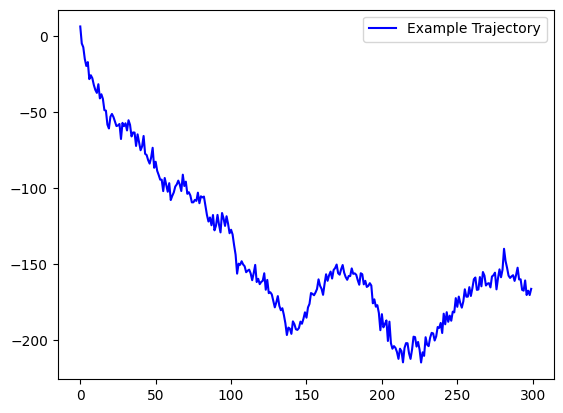

In [4]:
k = 120
n = 300
rho = 0.95
sigma2 = 2
tau2 = 20

X = simulate_ar1_cumsum_observations(k, n, rho, sigma2, tau2)[0]
X_train, X_test = train_test_split(X)
plt.plot(X_train[0, :], color="blue", label="Example Trajectory")
plt.legend()
plt.show()

In [5]:
def try_multiple_fits(X):
    fit_descriptions = ["Estimating rho and tau2:", "Estimating tau2, fixing rho = 0:", "Estimating rho, fixing tau2 = 0:"]
    fit_args = [{"fixed_rho": None, "fixed_tau2": None}, {"fixed_rho": 1e-6, "fixed_tau2": None}, {"fixed_rho": None, "fixed_tau2": 0}]
    fits = []
    for i, fit_arg in enumerate(fit_args):
        print(fit_descriptions[i])
        fit = fit_em_multiple_trajectories(X, fixed_rho=fit_arg["fixed_rho"], fixed_tau2=fit_arg["fixed_tau2"], max_iter=10**100, verbose=False)
        print()
        print(f"rho: {fit["rho"]}")
        print(f"sigma2: {fit["sigma2"]}")
        print(f"tau2: {fit["tau2"]}")
        print()
        fits.append(fit)
    return fits

fits = try_multiple_fits(X_train)

Estimating rho and tau2:

rho: 0.9548412604162597
sigma2: 2.1634796122980036
tau2: 19.84904546057164

Estimating tau2, fixing rho = 0:

rho: 1e-06
sigma2: 11.481582977958372
tau2: 14.329250521279526

Estimating rho, fixing tau2 = 0:

rho: 1e-06
sigma2: 42.19888466847519
tau2: 0.0



# Creating and Evaluating Prediction Intervals #

The following code takes in a fitted model and a matrix $X_\text{test}$, where each row of $X_\text{test}$ is assumed to be an independent trajectory from the fitted model. For each row $X$ of $X_\text{test}$, at each time $t$ for which this is possible, we produce a $95\%$ prediction interval for the *average* of the values $X_{t+(\text{lag}-1)(\text{step size})+1},\dots,X_{t+(\text{lag})(\text{step size})}$. Assuming $X$ represents weekly data, taking $(\text{step size})=1$ gives a $(\text{lag})$-week ahead prediction interval. Assuming $X$ represents daily data, taking $(\text{step size})=7$ gives a $(\text{lag})$-week ahead prediction interval for the average case count in $(\text{lag})$ weeks. The code then returns the average width of all prediction intervals across the entire matrix $X_\text{test}$ and their coverage.

In [6]:
def observation_covariance_from_fit(fit, n):
    """
    Build Cov(X_1, ..., X_n) under the fitted model.
    """
    rho = fit["rho"]
    sigma2 = fit["sigma2"]
    tau2 = fit["tau2"]

    K_U = ar1_covariance(sigma2, rho, n)
    L = cumulative_sum_matrix(n)

    # X = L U + eta, eta ~ N(0, tau2 I)
    S_X = L @ K_U @ L.T + tau2 * np.eye(n)

    return S_X


def evaluate_future_average_prediction_intervals(
    fit,
    X_test,
    step_size,
    lag,
    coverage_level=0.95,
    jitter=1e-9,
):
    """
    Evaluate prediction intervals for future block averages.

    Parameters
    ----------
    fit : dict
        Output of fit_em_multiple_trajectories. Must contain
        "rho", "sigma2", and "tau2".

    X_test : ndarray, shape (k_test, n)
        Test trajectories.

    step_size : int
        Block size. For example, if data are daily and step_size=7,
        then each block is one week.

    lag : int
        Which future block to predict.

        At time t, the target is the average of values strictly after

            X_{t + (lag - 1) * step_size}

        and up to and including

            X_{t + lag * step_size}.

        In other words, for lag=1 and step_size=7, the target is the
        average of the next 7 observations.

    coverage_level : float
        Nominal prediction interval coverage. Default is 0.95.

    jitter : float
        Small diagonal term added to covariance matrices for numerical stability.

    Returns
    -------
    result : dict with entries

        lower : ndarray, shape (k_test, n - lag * step_size)
            Prediction interval lower bounds.

        upper : ndarray, shape (k_test, n - lag * step_size)
            Prediction interval upper bounds.

        target_average : ndarray, shape (k_test, n - lag * step_size)
            Realized future averages being predicted.

        average_width : float
            Average width of all prediction intervals.

        coverage : float
            Empirical coverage over all rows and all valid times.

        predicted_mean : ndarray
            Conditional means of the future averages.

        predicted_sd : ndarray
            Conditional standard deviations of the future averages.
    """
    X_test = np.asarray(X_test, dtype=float)

    if X_test.ndim == 1:
        X_test = X_test[None, :]

    k_test, n = X_test.shape

    if step_size <= 0:
        raise ValueError("step_size must be positive.")

    if lag <= 0:
        raise ValueError("lag must be positive.")

    horizon = lag * step_size

    if horizon >= n:
        raise ValueError(
            "Need lag * step_size < n so that at least one prediction is possible."
        )

    num_times = n - horizon

    S_X = observation_covariance_from_fit(fit, n)

    alpha = 1.0 - coverage_level
    z = NormalDist().inv_cdf(1.0 - alpha / 2.0)

    lower = np.full((k_test, num_times), np.nan)
    upper = np.full((k_test, num_times), np.nan)
    predicted_mean = np.full((k_test, num_times), np.nan)
    predicted_sd = np.full((k_test, num_times), np.nan)
    target_average = np.full((k_test, num_times), np.nan)

    for t0 in range(num_times):
        # t0 is zero-based. We condition on X_1, ..., X_t,
        # where mathematical time t = t0 + 1.
        obs_idx = np.arange(t0 + 1)

        # Target indices are zero-based indices corresponding to
        #
        #   X_{t + (lag - 1) step_size + 1},
        #   ...,
        #   X_{t + lag step_size}.
        #
        # This is the block after t + (lag - 1) step_size,
        # up to and including t + lag step_size.
        target_idx = np.arange(
            t0 + (lag - 1) * step_size + 1,
            t0 + lag * step_size + 1,
        )

        # Realized target average in the test data.
        target_average[:, t0] = np.mean(X_test[:, target_idx], axis=1)

        S_obs = S_X[np.ix_(obs_idx, obs_idx)] + jitter * np.eye(len(obs_idx))

        # Cov(Y, X_obs), where Y is the average of X over target_idx.
        cov_y_obs = np.mean(S_X[np.ix_(target_idx, obs_idx)], axis=0)

        # Var(Y), where Y is the target average.
        S_target = S_X[np.ix_(target_idx, target_idx)]
        var_y = np.mean(S_target)

        # Conditional distribution:
        #
        #   Y | X_obs ~ N(
        #       Cov(Y, X_obs) Cov(X_obs)^{-1} X_obs,
        #       Var(Y) - Cov(Y, X_obs) Cov(X_obs)^{-1} Cov(X_obs, Y)
        #   )
        c, low = cho_factor(S_obs, lower=True, check_finite=False)

        # beta = S_obs^{-1} Cov(X_obs, Y)
        beta = cho_solve((c, low), cov_y_obs, check_finite=False)

        cond_var = var_y - cov_y_obs @ beta
        cond_var = max(float(cond_var), 0.0)

        X_obs = X_test[:, obs_idx]

        cond_mean = X_obs @ beta
        cond_sd = np.sqrt(cond_var)

        predicted_mean[:, t0] = cond_mean
        predicted_sd[:, t0] = cond_sd

        lower[:, t0] = cond_mean - z * cond_sd
        upper[:, t0] = cond_mean + z * cond_sd

    widths = upper - lower
    covered = (target_average >= lower) & (target_average <= upper)

    return {
        "lower": lower,
        "upper": upper,
        "target_average": target_average,
        "average_width": float(np.mean(widths)),
        "coverage": float(np.mean(covered)),
        "predicted_mean": predicted_mean,
        "predicted_sd": predicted_sd,
    }

# Evaluating Prediction Intervals on the Simulated Data #

In [7]:
def evaluate_prediction_intervals(fits, X_test, step_size, lag):
    fit_descriptions = ["rho and tau2 estimated", "tau2 estimated and rho = 0 fixed", "rho estimated and tau2 = 0 fixed"]
    results = []
    for i, fit in enumerate(fits):
        desc = fit_descriptions[i]
        print(f"Evaluating prediction intervals for model with {desc}:")
        result = evaluate_future_average_prediction_intervals(fit, X_test, step_size=step_size, lag=lag)
        print()
        print(f"Average width: {result["average_width"]}")
        print(f"Coverage: {result["coverage"]}")
        print()
        results.append(result)
    return results
        
step_size = 1
lag = 1       
results = evaluate_prediction_intervals(fits, X_test, step_size, lag)

Evaluating prediction intervals for model with rho and tau2 estimated:

Average width: 21.40639352077826
Coverage: 0.9460423634336678

Evaluating prediction intervals for model with tau2 estimated and rho = 0 fixed:

Average width: 22.895443056943286
Coverage: 0.948494983277592

Evaluating prediction intervals for model with rho estimated and tau2 = 0 fixed:

Average width: 25.464114179515107
Coverage: 0.9508361204013378



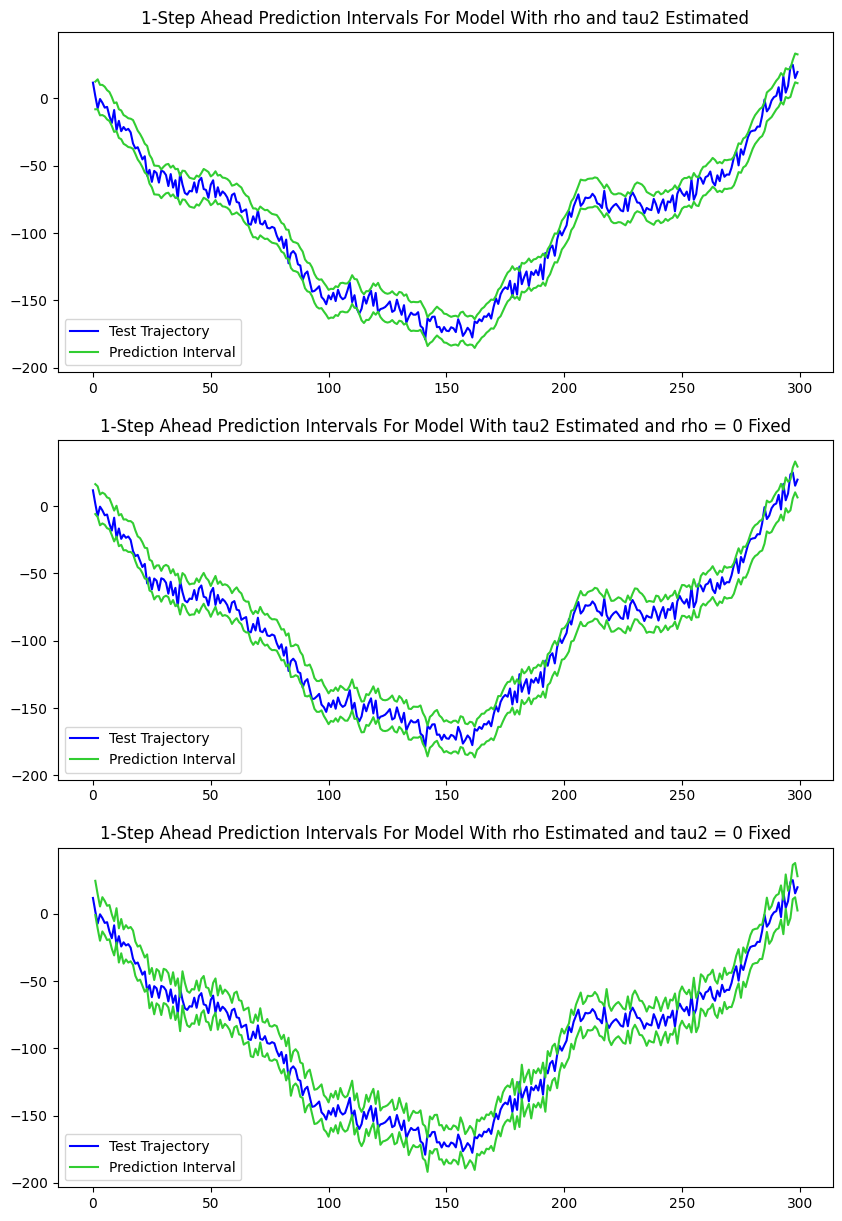

In [8]:
def plot_prediction_intervals(results, X_test, step_size, lag, step_name="Step"):
    fit_descriptions = ["rho and tau2 Estimated", "tau2 Estimated and rho = 0 Fixed", "rho Estimated and tau2 = 0 Fixed"]
    k, n = X_test.shape
    times = range(n)
    fig, axes = plt.subplots(3, figsize=(10, 15), sharey=True)
    for i, result in enumerate(results):
        axes[i].plot(times, X_test[0, :], color="blue", label="Test Trajectory")
        axes[i].plot(times[lag*step_size:], result["lower"][0, :], color="limegreen", label="Prediction Interval")
        axes[i].plot(times[lag*step_size:], result["upper"][0, :], color="limegreen")
        axes[i].set_title(f"{lag}-{step_name} Ahead Prediction Intervals For Model With {fit_descriptions[i]}")
        axes[i].legend()
    plt.show()

plot_prediction_intervals(results, X_test, step_size, lag)

# Evaluating the Models on Daily and Weekly Testing Data #

In [9]:
countries = ["Afghanistan", "Albania", "Argentina", "Australia", "Austria", "Azerbaijan", "Bahamas", "Bahrain", "Bangladesh", "Barbados", "Belarus", "Belgium", "Belize", "Bhutan", "Bolivia", "Bosnia and Herzegovina", "Brazil", "Bulgaria", "Burundi", "Cambodia", "Canada", "Central African Republic", "Chile", "China", "Colombia", "Costa Rica", "Croatia", "Cyprus", "Czechia", "Denmark", "Djibouti", "Dominica", "Dominican Republic", "Ecuador", "Egypt", "El Salvador", "Estonia", "Eswatini", "Ethiopia", "Fiji", "Finland", "France", "Gambia", "Georgia", "Germany", "Ghana", "Greece", "Guatemala", "Guinea", "Guyana", "Haiti", "Hungary", "Iceland", "India", "Indonesia", "Iran", "Iraq", "Ireland", "Israel", "Italy", "Jamaica", "Japan", "Jordan", "Kazakhstan", "Kuwait", "Laos", "Latvia", "Lebanon", "Libya", "Lithuania", "Luxembourg", "Malawi", "Malaysia", "Malta", "Mauritius", "Mexico", "Moldova", "Mongolia", "Morocco", "Mozambique", "Myanmar", "Nepal", "Netherlands", "New Zealand", "Nicaragua", "Niger", "Norway", "Oman", "Pakistan", "Panama", "Paraguay", "Peru", "Philippines", "Poland", "Portugal", "Qatar", "Romania", "Russia", "Saudi Arabia", "Serbia", "Singapore", "Slovakia", "Slovenia", "Somalia", "South Korea", "Spain", "Sri Lanka", "Suriname", "Sweden", "Switzerland", "Togo", "Trinidad and Tobago", "Tunisia", "Turkey", "Ukraine", "United Arab Emirates", "United Kingdom", "United States", "Uruguay", "Vietnam", "Zimbabwe"]

To ensure a fair comparison between daily and weekly data, we further restrict the set of countries in our data to ones for which the daily data is useable, i.e. countries that do not report 0 cases for 6 out of 7 days each week.

In [10]:
countries_subset = ["Afghanistan", "Albania", "Austria", "Azerbaijan", "Bahrain", "Bangladesh", "Belarus", "Belgium", "Bosnia and Herzegovina", "Brazil", "Burundi", "Cambodia", "Canada", "Central African Republic", "Chile", "China", "Colombia", "Costa Rica", "Croatia", "Czechia", "Denmark", "Dominican Republic", "Ecuador", "Egypt", "Eswatini", "Ethiopia", "Finland", "Georgia", "Guatemala", "Guinea", "Guyana", "India", "Indonesia", "Iran", "Iraq", "Ireland", "Israel", "Italy", "Jamaica", "Japan", "Kazakhstan", "Kuwait", "Laos", "Lebanon", "Lithuania", "Malawi", "Malaysia", "Mexico", "Moldova", "Morocco", "Mozambique", "Myanmar", "Nepal", "New Zealand", "Niger", "Norway", "Pakistan", "Paraguay", "Peru", "Philippines", "Poland", "Qatar", "Romania", "Russia", "Saudi Arabia", "Serbia", "Singapore", "Slovakia", "South Korea", "Sri Lanka", "Suriname", "Switzerland", "Togo", "Turkey", "United Arab Emirates", "United Kingdom", "United States", "Vietnam", "Zimbabwe"]

In [11]:
df_daily = pd.read_csv("../../data/owid_covid_data.csv")
df_daily = df_daily[df_daily["date"] >= "2020-01-13"]
df_daily = df_daily[df_daily["date"] <= "2022-05-23"]
df_daily = df_daily[df_daily["country"].isin(countries_subset)]
df_daily = df_daily[["country", "date", "new_cases_per_million"]]
df_daily = df_daily.fillna(0)
df_daily["log_cases"] = np.log(1 + df_daily["new_cases_per_million"])

df_weekly = pd.read_csv("../../data/covid_seasonal.csv")
df_weekly = df_weekly[df_weekly["country"].isin(countries)]
df_weekly = df_weekly[["country", "date", "log_cases"]]

### Testing Daily Data ###

In [12]:
def create_X_from_df(df):
    df_sorted = df.sort_values(["country", "date"])
    X = df_sorted.pivot(
        index="country",
        columns="date",
        values="log_cases"
    )
    return X.to_numpy()

X = create_X_from_df(df_daily)
k, n = X.shape
train, test = train_test_split(range(k))
X_train, X_test = X[train, :], X[test, :]

In [13]:
fits = try_multiple_fits(X_train)

Estimating rho and tau2:

rho: 1e-06
sigma2: 0.02173590938394601
tau2: 0.1331717250519173

Estimating tau2, fixing rho = 0:

rho: 1e-06
sigma2: 0.021735908436555137
tau2: 0.13317172584557777

Estimating rho, fixing tau2 = 0:

rho: 1e-06
sigma2: 0.274289839302328
tau2: 0.0



In [14]:
step_size = 7
lag = 1
results = evaluate_prediction_intervals(fits, X_test, step_size=step_size, lag=lag)

Evaluating prediction intervals for model with rho and tau2 estimated:

Average width: 1.3863864306159117
Coverage: 0.9411111111111111

Evaluating prediction intervals for model with tau2 estimated and rho = 0 fixed:

Average width: 1.386386412843148
Coverage: 0.9411111111111111

Evaluating prediction intervals for model with rho estimated and tau2 = 0 fixed:

Average width: 3.4701581846812104
Coverage: 0.9901169590643275



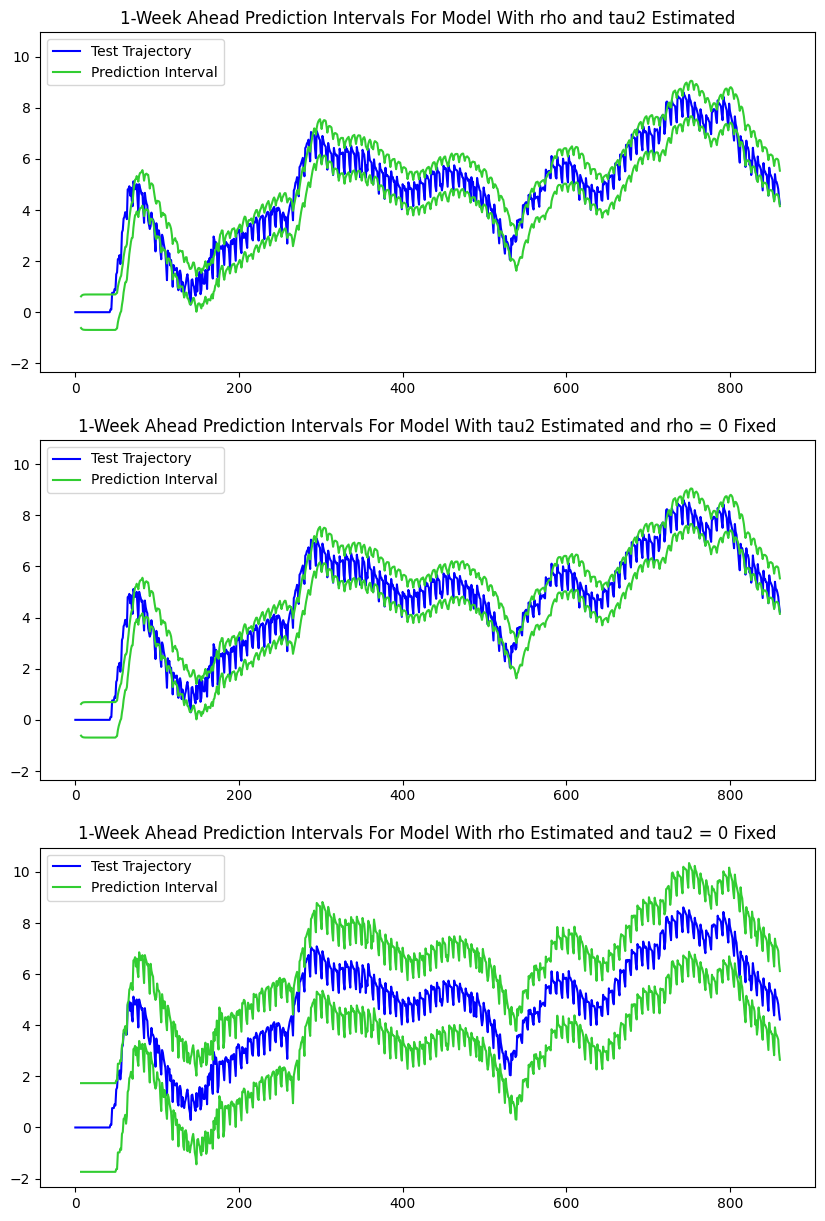

In [15]:
plot_prediction_intervals(results, X_test, step_size=step_size, lag=lag, step_name="Week")

### Testing Weekly Data ###

In [16]:
X = create_X_from_df(df_weekly)
X_train, X_test = X[train, :], X[test, :]

In [17]:
fits = try_multiple_fits(X_train)

Estimating rho and tau2:

rho: 0.5845624884622732
sigma2: 0.16320294168089072
tau2: 0.030679477717726552

Estimating tau2, fixing rho = 0:

rho: 1e-06
sigma2: 0.22364451794948842
tau2: 2.0680805455780766e-05

Estimating rho, fixing tau2 = 0:

rho: 0.27415392810197514
sigma2: 0.22427874481564788
tau2: 0.0



In [18]:
step_size = 1
lag = 1
results = evaluate_prediction_intervals(fits, X_test, step_size=step_size, lag=lag)

Evaluating prediction intervals for model with rho and tau2 estimated:

Average width: 1.7483747720545413
Coverage: 0.9406504065040651

Evaluating prediction intervals for model with tau2 estimated and rho = 0 fixed:

Average width: 1.853947239546756
Coverage: 0.9439024390243902

Evaluating prediction intervals for model with rho estimated and tau2 = 0 fixed:

Average width: 1.7852759769715674
Coverage: 0.9422764227642276



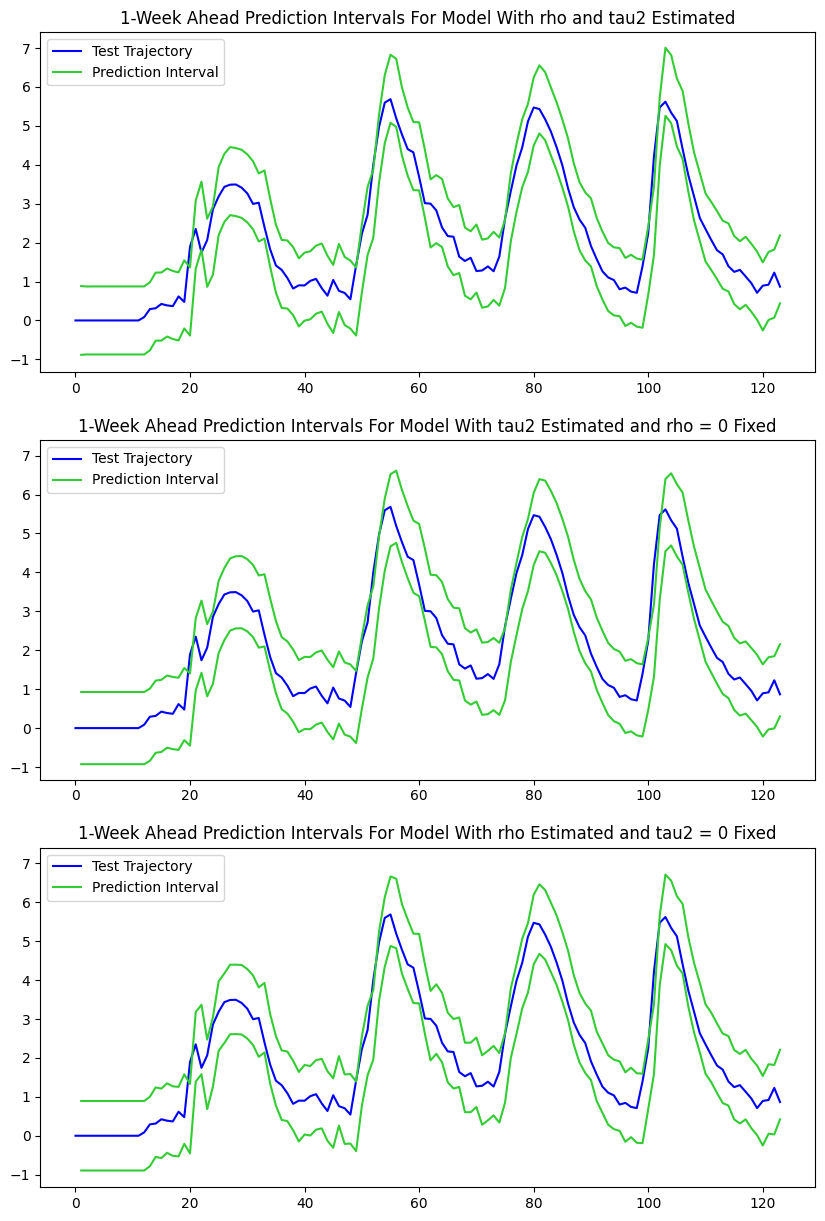

In [19]:
plot_prediction_intervals(results, X_test, step_size=step_size, lag=lag, step_name="Week")